# Tutorial 7: multimodal models: CLIP, a tiny VLM, and the modality gap
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T07_multimodal.ipynb)
Recap slides: [T07_multimodal_recap.pdf](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T07_multimodal_recap.pdf)

Plan for today (≈ 60 min):
1. Lecture recap: fusion vs coordination, CLIP/SigLIP, the VLM recipe, unified and omni models (10 min)
2. CLIP: the symmetric InfoNCE loss, and zero-shot CIFAR-10 by prompting (12 min)
3. A tiny VLM: frozen CLIP vision tower + linear projector + frozen GPT-2 (15 min)
4. Early fusion (one small transformer over pixel patches and words) vs projector-into-LM (8 min)
5. Asking about an object that is not there: hallucination (5 min)
6. The modality gap: image and text embeddings live in two separate cones (10 min)
7. Optional, GPU only: Janus-Pro-1B, one transformer that reads and draws images
8. If time: a prefix-LM mask vs a fully causal mask

Runs on a laptop CPU in about 5–10 minutes (downloads CLIP ViT-B/32, 600 MB, and GPT-2, 500 MB, on first run). Cells marked ✏️ are for you to try.

In [1]:
import math, random, re, time, warnings
warnings.filterwarnings("ignore", message="IProgress not found")
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import CLIPModel, CLIPProcessor, AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
cpu = "cpu"   # the small experiments below are run on CPU so the numbers are the same everywhere
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device:", device)
T_START = time.time()

device: mps


## 1. Lecture recap

**Fusion vs coordination.** *Fusion* builds one joint representation $z = f(x_A, x_B)$ (early fusion: concatenate inputs or tokens; late fusion: combine per-modality predictions). *Coordination* keeps two encoders $z_A = f_A(x_A)$, $z_B = f_B(x_B)$ and only ties them by a coordination function, e.g. cosine similarity $g(z_A,z_B)=\frac{z_A^\top z_B}{\|z_A\|\|z_B\|}$.

**CLIP (Radford et al., 2021)** is coordination at scale: 400M image–text pairs, an image encoder and a text encoder, and a batch of $N$ pairs scored by the $N\times N$ matrix of cosine similarities $s_{ij} = \hat u_i^\top \hat v_j$. The loss is a symmetric InfoNCE (cross-entropy along rows and along columns) with a learned temperature $\tau$:
$$\mathcal L = \tfrac12\Big[\tfrac1N\textstyle\sum_i -\log \frac{e^{s_{ii}/\tau}}{\sum_j e^{s_{ij}/\tau}} \;+\; \tfrac1N\sum_j -\log \frac{e^{s_{jj}/\tau}}{\sum_i e^{s_{ij}/\tau}}\Big].$$
**SigLIP** replaces the softmax by an independent sigmoid on every pair, $\mathcal L = -\frac1N\sum_{i,j}\log\sigma\big(y_{ij}(s_{ij}/\tau + b)\big)$ with $y_{ii}=1$, $y_{i\neq j}=-1$: no normalization over the batch, so it scales to large batches more cheaply.

**Zero-shot transfer.** A classifier is built from text: embed "a photo of a {class}." for every class, and predict $\arg\max_c \hat u^\top \hat t_c$. No training images of these classes are used.

**The VLM recipe (LLaVA → Qwen3-VL).** Vision encoder (CLIP or SigLIP ViT) → patch features $Z_v$ → projector $H_v = W Z_v$ (linear in LLaVA, a 2-layer MLP from LLaVA-1.5 on) → the visual tokens are placed in the LLM's input sequence next to the text tokens, and the LLM is trained with the usual next-token loss on the answer. 2025–26 models (Qwen2.5/3-VL) keep the recipe and change the details: native resolution (a variable number of patches, 2D/3D RoPE), video frames with timestamps, features from several encoder layers. **Grounding as text**: boxes and points are written as coordinates in the output text (e.g. `[x1, y1, x2, y2]`), so detection needs no new head.

**Unified models: tokens in, tokens out.** To *generate* images with the same next-token machinery, the image is turned into discrete tokens by a VQ tokenizer (a second vocabulary).
- **Chameleon** (Meta, 2024): early fusion; text and VQ image tokens in one vocabulary, one transformer trained from scratch on both.
- **Janus** (DeepSeek, 2024) and **Janus-Pro** (2025): *decouple the visual encoders, keep one transformer.* Understanding uses a SigLIP encoder (semantic features, continuous, through an adaptor); generation uses a VQ tokenizer (pixel-preserving codes, discrete, predicted by a separate head). Why: understanding needs high-level semantics, generation needs low-level detail to reconstruct pixels, and one shared encoder compromises both. Decoupled, each pathway gets the representation its task needs while the autoregressive transformer is shared. Janus-Pro keeps the architecture and changes the training recipe, scales the data, and scales to 7B; it improves text-to-image instruction following and stability.
- **Transfusion** (Meta, 2024): one transformer, next-token loss on text tokens and a diffusion loss on continuous image patches. Products such as GPT-4o native image generation and Gemini's image models apply this "one model reads and writes images" idea.

**Omni models**: any modality in (text, image, audio, video), text and speech out. Qwen2.5/3-Omni split it into a *Thinker* (the LLM, time-aligned multimodal RoPE) and a *Talker* that streams speech tokens from the Thinker's hidden states.

## 2. CLIP: the loss, and zero-shot classification

We load `openai/clip-vit-base-patch32` (ViT-B/32 image tower, 12-layer text tower, both projected to 512-d). We compute the embeddings ourselves, `projection(tower(x).pooler_output)`, so the code does not depend on the `transformers` version.

In [2]:
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
for p in clip.parameters(): p.requires_grad_(False)

@torch.no_grad()
def embed_images(pil_images, bs=100):
    out = []
    for i in range(0, len(pil_images), bs):
        px = proc(images=pil_images[i:i + bs], return_tensors="pt").pixel_values
        out.append(clip.visual_projection(clip.vision_model(pixel_values=px).pooler_output))
    return torch.cat(out)

@torch.no_grad()
def embed_texts(texts):
    tok = proc(text=texts, return_tensors="pt", padding=True)
    return clip.text_projection(clip.text_model(**tok).pooler_output)

print("learned temperature: 1/tau = logit_scale.exp() =", round(clip.logit_scale.exp().item(), 2))

learned temperature: 1/tau = logit_scale.exp() = 100.0


**The loss.** `img`, `txt` are $N\times d$ (row $i$ of each is a matching pair). Normalize, compute the $N\times N$ logits $s_{ij}/\tau$, and average the cross-entropy over rows (image → text) and over columns (text → image). CLIP stores $\log(1/\tau)$ as `logit_scale`, initialized to $\log(1/0.07)$ and clipped at 100.

In [3]:
def clip_loss(img, txt, logit_scale):
    img, txt = F.normalize(img, dim=-1), F.normalize(txt, dim=-1)
    logits = logit_scale.exp() * img @ txt.T
    targets = torch.arange(len(img))
    return (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2

**Check: against `CLIPModel(..., return_loss=True)`** on 10 CIFAR-10 test images (one per class) paired with "a photo of a {class}.".

In [4]:
cifar = torchvision.datasets.CIFAR10("./data", train=False, download=True)
classes = cifar.classes
labels_all = np.array(cifar.targets)
idx = np.concatenate([np.where(labels_all == c)[0][:50] for c in range(10)])   # 50 test images per class
cifar_imgs = [cifar[i][0] for i in idx]
cifar_y = torch.tensor(labels_all[idx])

batch_imgs = [cifar_imgs[c * 50] for c in range(10)]
batch_txts = [f"a photo of a {c}." for c in classes]
with torch.no_grad():
    ref = clip(**proc(text=batch_txts, images=batch_imgs, return_tensors="pt", padding=True), return_loss=True).loss
mine = clip_loss(embed_images(batch_imgs), embed_texts(batch_txts), clip.logit_scale)
print(f"mine {mine.item():.5f}   CLIPModel {ref.item():.5f}   |diff| = {abs(mine - ref).item():.2e}")

mine 0.26984   CLIPModel 0.26984   |diff| = 5.07e-07


**Zero-shot classification.** One text embedding per class is the classifier's weight vector. With several prompt templates, normalize each template's embedding, average over templates, and normalize again (prompt ensembling, as in the CLIP paper). We compare three prompt sets on 500 CIFAR-10 test images.

In [5]:
def zero_shot_weights(classnames, templates):
    W = []
    for c in classnames:
        t = F.normalize(embed_texts([tm.format(c) for tm in templates]), dim=-1)
        W.append(F.normalize(t.mean(0), dim=-1))
    return torch.stack(W)

t0 = time.time()
cifar_emb = F.normalize(embed_images(cifar_imgs), dim=-1)            # (500, 512)
print(f"embedded {len(cifar_imgs)} images in {time.time() - t0:.0f} s")

embedded 500 images in 13 s


**Check:** with a single template, our logits $\frac1\tau \hat u^\top \hat t_c$ must equal `CLIPModel`'s `logits_per_image`.

In [6]:
W1 = zero_shot_weights(classes, ["a photo of a {}."])
with torch.no_grad():
    ref = clip(**proc(text=[f"a photo of a {c}." for c in classes], images=cifar_imgs[:20], return_tensors="pt", padding=True)).logits_per_image
mine = clip.logit_scale.exp() * cifar_emb[:20] @ W1.T
print("max |mine − CLIPModel| =", (mine - ref).abs().max().item())

max |mine − CLIPModel| = 3.4332275390625e-05


In [7]:
prompt_sets = {
    "class name only": ["{}"],
    '"a photo of a {}."': ["a photo of a {}."],
    "8-template ensemble": ["a photo of a {}.", "a blurry photo of a {}.", "a low resolution photo of a {}.",
                            "a photo of the small {}.", "a pixelated photo of a {}.", "a close-up photo of a {}.",
                            "a bright photo of a {}.", "a photo of the big {}."],
}
zs_acc = {}
for name, templates in prompt_sets.items():
    W = zero_shot_weights(classes, templates)
    pred = (cifar_emb @ W.T).argmax(1)
    zs_acc[name] = (pred == cifar_y).float().mean().item()
    print(f"{name:22s} zero-shot accuracy: {zs_acc[name]:.3f}")

class name only        zero-shot accuracy: 0.880


"a photo of a {}."     zero-shot accuracy: 0.898


8-template ensemble    zero-shot accuracy: 0.916


Class names alone give 88.0%. Writing the class name as a caption, "a photo of a {}.", gives 89.8%, and averaging 8 templates gives 91.6% (the CLIP paper reports 91.3% for ViT-B/32 on the full CIFAR-10 test set). The text encoder was trained on captions, not on single words, so a prompt that reads like a caption is closer to its training data. Averaging several templates also reduces the noise of any one phrasing. Prompt engineering here costs no training and gains 3.6 points.

✏️ Add the template `"a photo of a {}, a type of vehicle."` alone. What happens to the animal classes? Print the confusion matrix (`sklearn.metrics.confusion_matrix`) for the worst template.

## 3. A tiny VLM: frozen vision encoder + linear projector + frozen LM

**Data.** A real captioning set does not train on a CPU in minutes, so we draw our own: 64×64 images with two shapes (left and right), each with a color from {red, green, blue, yellow} and a shape from {circle, square, triangle} (the two shapes differ). Two kinds of text per image:
- caption: `Caption: a red circle left of a blue square.`
- question: `Question: what color is the square? Answer: blue.` (only about shapes that are in the image, as in most instruction data)

2,000 training and 200 test images.

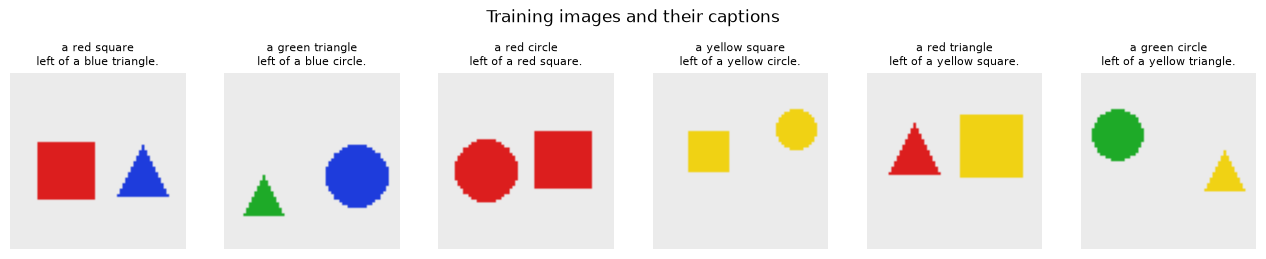

In [8]:
COLORS = {"red": (220, 30, 30), "green": (30, 170, 40), "blue": (30, 60, 220), "yellow": (240, 210, 20)}
SHAPES = ["circle", "square", "triangle"]

def draw_shape(d, shape, cx, cy, r, col):
    if shape == "circle":   d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=col)
    elif shape == "square": d.rectangle([cx - r, cy - r, cx + r, cy + r], fill=col)
    else:                   d.polygon([(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)], fill=col)

def make_scene(rng):
    s1, s2 = rng.sample(SHAPES, 2)
    c1, c2 = rng.choice(list(COLORS)), rng.choice(list(COLORS))
    img = Image.new("RGB", (64, 64), (235, 235, 235)); d = ImageDraw.Draw(img)
    for s, c, x0 in [(s1, c1, 16), (s2, c2, 48)]:
        draw_shape(d, s, x0 + rng.randint(-4, 4), 32 + rng.randint(-12, 12), rng.randint(7, 11), COLORS[c])
    return img, [(c1, s1), (c2, s2)]

def caption_of(objs): return f"a {objs[0][0]} {objs[0][1]} left of a {objs[1][0]} {objs[1][1]}."

def sample_text(objs, rng):
    if rng.random() < 0.5:
        return "Caption: " + caption_of(objs)
    c, s = rng.choice(objs)
    return f"Question: what color is the {s}? Answer: {c}."

rng = random.Random(0)
N_TR, N_TE = 2000, 200
scenes = [make_scene(rng) for _ in range(N_TR + N_TE)]
shape_imgs, shape_objs = [s[0] for s in scenes], [s[1] for s in scenes]
test_ids = list(range(N_TR, N_TR + N_TE))

fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
for ax, i in zip(axes, range(6)):
    ax.imshow(shape_imgs[i]); ax.axis("off"); ax.set_title(caption_of(shape_objs[i]).replace(" left of", "\nleft of"), fontsize=8)
plt.suptitle("Training images and their captions"); plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

**Visual tokens.** We run the frozen CLIP vision tower once over all images and keep the **penultimate layer** (as LLaVA does): 1 CLS token + a 7×7 grid of patch tokens, 768-d each. To keep GPT-2's sequence short on a CPU we average-pool the grid to 2×2, giving **5 visual tokens per image**. (LLaVA keeps all patches; on a GPU you can too: drop the pooling.)

In [9]:
@torch.no_grad()
def visual_tokens(pil_images, bs=100):
    out = []
    for i in range(0, len(pil_images), bs):
        px = proc(images=pil_images[i:i + bs], return_tensors="pt").pixel_values
        h = clip.vision_model(pixel_values=px, output_hidden_states=True).hidden_states[-2]   # (B, 50, 768)
        grid = h[:, 1:].reshape(-1, 7, 7, 768).permute(0, 3, 1, 2)                             # (B, 768, 7, 7)
        pooled = F.adaptive_avg_pool2d(grid, 2).flatten(2).transpose(1, 2)                   # (B, 4, 768)
        out.append(torch.cat([h[:, :1], pooled], 1))                                         # (B, 5, 768)
    return torch.cat(out)

t0 = time.time()
vis = visual_tokens(shape_imgs)
mu, sd = vis[:N_TR].mean((0, 1)), vis[:N_TR].std((0, 1))
vis = (vis - mu) / sd                       # standardize each feature (training-set statistics)
print("visual tokens:", tuple(vis.shape), f"in {time.time() - t0:.0f} s")

visual tokens: (2200, 5, 768) in 55 s


**The model.** GPT-2 (124M) frozen; the only trainable part is the projector $W\in\mathbb R^{768\times 768}$ mapping each visual token into GPT-2's input embedding space. The input sequence is `[5 projected visual tokens] + [text token embeddings]`, passed as `inputs_embeds`. The loss is next-token cross-entropy on the text only: the labels at the visual positions are set to $-100$, which `cross_entropy` ignores.

In [10]:
tok = AutoTokenizer.from_pretrained("gpt2")
lm = AutoModelForCausalLM.from_pretrained("gpt2").eval()
wte = lm.get_input_embeddings()
N_VIS = vis.shape[1]

for p in lm.parameters():
    p.requires_grad_(False)
torch.manual_seed(0)
projector = nn.Linear(768, lm.config.n_embd)
INIT_SCALE = 0.2                            # see the note below
with torch.no_grad():
    projector.weight.mul_(INIT_SCALE); projector.bias.zero_()
with torch.no_grad():
    print(f"per-dim std: GPT-2 token embeddings {wte.weight.std():.3f}, projected visual tokens at init {projector(vis[:200]).std():.3f}")

def build_batch(ids_list, img_idx):
    # returns inputs_embeds (B, N_VIS+L, d), attention_mask (B, N_VIS+L), labels (B, N_VIS+L)
    L = max(len(x) for x in ids_list); Bsz = len(ids_list)
    ids = torch.full((Bsz, L), tok.eos_token_id)
    text_mask = torch.zeros(Bsz, L, dtype=torch.long)
    for j, x in enumerate(ids_list):
        ids[j, :len(x)] = torch.tensor(x); text_mask[j, :len(x)] = 1
    embeds = torch.cat([projector(vis[img_idx]), wte(ids)], 1)
    attn = torch.cat([torch.ones(Bsz, N_VIS, dtype=torch.long), text_mask], 1)
    labels = torch.cat([torch.full((Bsz, N_VIS), -100), ids.masked_fill(text_mask == 0, -100)], 1)
    return embeds, attn, labels

n_train = sum(p.numel() for p in projector.parameters())
n_frozen = sum(p.numel() for p in lm.parameters())
print(f"trainable (projector): {n_train:,}   frozen (GPT-2): {n_frozen:,}   trainable LM params: {sum(p.numel() for p in lm.parameters() if p.requires_grad)}")

per-dim std: GPT-2 token embeddings 0.144, projected visual tokens at init 0.115
trainable (projector): 590,592   frozen (GPT-2): 124,439,808   trainable LM params: 0


**Check:** our next-token loss (shift by one, ignore $-100$) must equal the loss GPT-2 computes from `labels=`.

In [11]:
texts = [sample_text(shape_objs[i], rng) + tok.eos_token for i in range(4)]
emb, attn, labels = build_batch([tok(t).input_ids for t in texts], torch.arange(4))
out = lm(inputs_embeds=emb, attention_mask=attn, labels=labels)
logits = out.logits[:, :-1]; target = labels[:, 1:]
mine = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), target.reshape(-1), ignore_index=-100)
print(f"mine {mine.item():.5f}   GPT-2 {out.loss.item():.5f}   |diff| = {abs(mine - out.loss).item():.2e}")
assert labels[:, :N_VIS].eq(-100).all(), "no loss on the visual positions"

mine 5.34480   GPT-2 5.34480   |diff| = 0.00e+00


**Projector init scale.** The visual tokens enter a frozen LM that has only ever seen its own token embeddings. PyTorch's default `nn.Linear` init applied to our standardized features gives outputs several times larger than GPT-2's embeddings, so we shrink the initial weights by `INIT_SCALE = 0.2`. In our runs this one line moved the caption exact match after 200 steps from about 0.4 (default init) to about 0.9.

**Train the projector.** AdamW, one-cycle schedule, batch 32. Each step samples images and, for each, a caption or a question.

*Scaling up on a Colab GPU:* move `lm`, `projector` and `vis` to `device`, drop the 2×2 pooling (all 50 visual tokens, as LLaVA), train for 1,000+ steps, or swap GPT-2 for `HuggingFaceTB/SmolLM2-360M`; on real data (e.g. COCO captions) this is ClipCap / LLaVA stage 1.

In [12]:
VLM_STEPS, VLM_LR, BS = 200, 3e-3, 32
opt = torch.optim.AdamW(projector.parameters(), lr=VLM_LR)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, VLM_LR, total_steps=VLM_STEPS, pct_start=0.1)
rng = random.Random(1); torch.manual_seed(1)
vlm_losses, t0 = [], time.time()
for step in range(VLM_STEPS):
    img_idx = torch.randint(0, N_TR, (BS,))
    ids_list = [tok(sample_text(shape_objs[i], rng) + tok.eos_token).input_ids for i in img_idx.tolist()]
    emb, attn, labels = build_batch(ids_list, img_idx)
    loss = lm(inputs_embeds=emb, attention_mask=attn, labels=labels).loss
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    vlm_losses.append(loss.item())
    if step % 40 == 0 or step == VLM_STEPS - 1:
        print(f"step {step:3d}  loss {loss.item():.3f}  ({time.time() - t0:.0f} s)")
vlm_time = time.time() - t0

step   0  loss 5.121  (2 s)


step  40  loss 0.811  (61 s)


step  80  loss 0.272  (102 s)


step 120  loss 0.185  (142 s)


step 160  loss 0.143  (191 s)


step 199  loss 0.163  (239 s)


**Greedy decoding from embeddings.** At each step, run the LM on the whole sequence so far, take the argmax of the last position's logits, and append that token's embedding. (No KV cache, so each step recomputes the prefix: fine for 12 tokens.)

In [13]:
@torch.no_grad()
def greedy_from_embeds(embeds, n_new):
    out = []
    for _ in range(n_new):
        nxt = lm(inputs_embeds=embeds).logits[:, -1].argmax(-1)
        out.append(nxt)
        embeds = torch.cat([embeds, wte(nxt)[:, None]], 1)
    return torch.stack(out, 1)

@torch.no_grad()
def prompt_embeds(img_idx, prompt):
    p = torch.tensor(tok(prompt).input_ids)
    return torch.cat([projector(vis[img_idx]), wte(p).expand(len(img_idx), -1, -1)], 1)

**Check:** the same tokens as Hugging Face's `generate(inputs_embeds=..., do_sample=False)`.

In [14]:
e = prompt_embeds(torch.tensor(test_ids[:8]), "Caption:")
mine = greedy_from_embeds(e, 12)
ref = lm.generate(inputs_embeds=e, attention_mask=torch.ones(e.shape[:2], dtype=torch.long),
                  max_new_tokens=12, do_sample=False, pad_token_id=tok.eos_token_id)
# generate() stops once every row has emitted <eos>; compare up to and including each row's first <eos>
valid = (ref == tok.eos_token_id).long().cumsum(1).roll(1, 1).index_fill(1, torch.tensor([0]), 0) == 0
print("identical tokens:", (mine[:, :ref.shape[1]] == ref)[valid].float().mean().item(), f"({valid.sum().item()} tokens compared)")

identical tokens: 1.0 (80 tokens compared)


In [15]:
def first_sentence(s):
    s = s.strip()
    return s[: s.index(".") + 1] if "." in s else s

def vlm_generate(img_ids, prompt, n_new=12):
    toks = greedy_from_embeds(prompt_embeds(torch.tensor(img_ids), prompt), n_new)
    return [first_sentence(t) for t in tok.batch_decode(toks, skip_special_tokens=True)]

PAT = re.compile(r"a (\w+) (\w+) left of a (\w+) (\w+)\.")
def score_captions(preds, img_ids):
    # returns: exact-match rate, color accuracy, shape accuracy (over both objects)
    exact, col, shp = [], [], []
    for p, i in zip(preds, img_ids):
        o = shape_objs[i]; truth = [o[0][0], o[0][1], o[1][0], o[1][1]]
        m = PAT.fullmatch(p)
        got = list(m.groups()) if m else [None] * 4
        exact.append(got == truth)
        col += [got[0] == truth[0], got[2] == truth[2]]; shp += [got[1] == truth[1], got[3] == truth[3]]
    return np.mean(exact), np.mean(col), np.mean(shp)

vlm_caps = vlm_generate(test_ids, "Caption:")
vlm_exact, vlm_col, vlm_shp = score_captions(vlm_caps, test_ids)
qa_ok = []
for i in test_ids:
    c, s = shape_objs[i][0]
    qa_ok.append(vlm_generate([i], f"Question: what color is the {s}? Answer:", 3)[0].startswith(c))
vlm_qa = np.mean(qa_ok)
print(f"tiny VLM on {N_TE} test images: caption exact match {vlm_exact:.2f} (colors {vlm_col:.2f}, shapes {vlm_shp:.2f}); QA accuracy {vlm_qa:.2f}")

tiny VLM on 200 test images: caption exact match 0.91 (colors 0.92, shapes 0.96); QA accuracy 0.74


GPT-2 was not trained at all; only the 590k projector weights were (0.5% of the parameters). After 200 steps the frozen LM writes the exact caption for 91% of the test images and answers the color question correctly for 74%. The projector learned to write input embeddings ("soft prompts") that GPT-2 reads as a description of the image. This is the LLaVA stage-1 recipe (align the projector on captions, LLM frozen), at toy scale.

## 4. Early fusion vs projector-into-LM

**Early fusion** (ViLT, Fuyu, Chameleon): no pretrained encoder and no pretrained LM. Cut the raw image into 16×16-pixel patches, embed each patch and each word linearly, concatenate them into **one sequence**, and train one small transformer from scratch with the next-token loss on the words. Same data, same captions and questions; a word-level vocabulary.

The mask is a **prefix-LM** mask: visual tokens attend to each other freely, text tokens attend to all visual tokens and to earlier text tokens only.

In [16]:
P = 16
pixels = torch.stack([torch.from_numpy(np.array(im)).permute(2, 0, 1).float() / 255 for im in shape_imgs])   # (N, 3, 64, 64)

def patchify(x, p=P):
    Bsz, C, H, W = x.shape
    return x.unfold(2, p, p).unfold(3, p, p).permute(0, 2, 3, 1, 4, 5).reshape(Bsz, (H // p) * (W // p), C * p * p)

def prefix_lm_mask(n_img, n_txt):
    # True = may NOT attend (PyTorch convention for a boolean attn_mask)
    T = n_img + n_txt
    m = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
    m[:n_img, :n_img] = False
    return m

ref = F.unfold(pixels[:4], kernel_size=P, stride=P).transpose(1, 2)
print("patchify vs F.unfold, max |diff| =", (patchify(pixels[:4]) - ref).abs().max().item())
print(prefix_lm_mask(3, 3).int())

patchify vs F.unfold, max |diff| = 0.0
tensor([[0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)


In [17]:
WORDS = sorted(set("caption: question: what color is the ? answer: a left of . <eos> <pad>".split()) | set(COLORS) | set(SHAPES))
w2i = {w: i for i, w in enumerate(WORDS)}
def wtok(s): return [w2i[w] for w in s.replace("?", " ?").replace(".", " .").lower().split()]

class EarlyFusion(nn.Module):
    def __init__(self, vocab, d=128, layers=4, heads=4, n_img=16, max_txt=24):
        super().__init__()
        self.n_img = n_img
        self.patch = nn.Linear(3 * P * P, d); self.word = nn.Embedding(vocab, d)
        self.modality = nn.Embedding(2, d)                       # 0 = image token, 1 = text token
        self.pos = nn.Parameter(torch.randn(n_img + max_txt, d) * 0.02)
        layer = nn.TransformerEncoderLayer(d, heads, 4 * d, dropout=0.0, batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
        self.ln, self.head = nn.LayerNorm(d), nn.Linear(d, vocab)
    def forward(self, x, ids):
        z = torch.cat([self.patch(patchify(x)) + self.modality.weight[0], self.word(ids) + self.modality.weight[1]], 1)
        z = z + self.pos[: z.shape[1]]
        h = self.blocks(z, mask=prefix_lm_mask(self.n_img, ids.shape[1]))
        return self.head(self.ln(h))[:, self.n_img:]             # logits at the text positions

def ef_batch(img_idx, rng):
    seqs = [wtok(sample_text(shape_objs[i], rng)) + [w2i["<eos>"]] for i in img_idx.tolist()]
    L = max(map(len, seqs)); ids = torch.full((len(seqs), L), w2i["<pad>"])
    for j, s in enumerate(seqs): ids[j, :len(s)] = torch.tensor(s)
    return ids

torch.manual_seed(0)
ef = EarlyFusion(len(WORDS))
EF_STEPS, EF_LR = 1000, 2e-3
opt = torch.optim.AdamW(ef.parameters(), lr=EF_LR, weight_decay=0.01)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, EF_LR, total_steps=EF_STEPS, pct_start=0.1)
rng = random.Random(1)
t0 = time.time()
for step in range(EF_STEPS):
    img_idx = torch.randint(0, N_TR, (64,))
    ids = ef_batch(img_idx, rng)
    logits = ef(pixels[img_idx], ids[:, :-1])
    target = ids[:, 1:].masked_fill(ids[:, 1:] == w2i["<pad>"], -100)
    loss = F.cross_entropy(logits.reshape(-1, len(WORDS)), target.reshape(-1), ignore_index=-100)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    if step % 200 == 0 or step == EF_STEPS - 1:
        print(f"step {step:4d}  loss {loss.item():.3f}  ({time.time() - t0:.0f} s)")
ef_time = time.time() - t0

step    0  loss 3.187  (0 s)


step  200  loss 0.314  (28 s)


step  400  loss 0.294  (48 s)


step  600  loss 0.183  (66 s)


step  800  loss 0.146  (86 s)


step  999  loss 0.141  (106 s)


In [18]:
@torch.no_grad()
def ef_generate(img_ids, prompt, n_new=12):
    img_ids = torch.tensor(img_ids)
    ids = torch.tensor(wtok(prompt)).expand(len(img_ids), -1)
    for _ in range(n_new):
        ids = torch.cat([ids, ef(pixels[img_ids], ids)[:, -1].argmax(-1, keepdim=True)], 1)
    outs = []
    for row in ids[:, len(wtok(prompt)):].tolist():
        ws = [WORDS[k] for k in row]
        ws = ws[: ws.index("<eos>")] if "<eos>" in ws else ws
        outs.append(first_sentence(" ".join(ws).replace(" .", ".").replace(" ?", "?")))
    return outs

ef_caps = ef_generate(test_ids, "caption:")
ef_exact, ef_col, ef_shp = score_captions(ef_caps, test_ids)
ef_qa = np.mean([ef_generate([i], f"question: what color is the {shape_objs[i][0][1]}? answer:", 2)[0].startswith(shape_objs[i][0][0]) for i in test_ids])

n_ef = sum(p.numel() for p in ef.parameters())
print(f"{'':28s}{'trainable':>11s}{'steps':>7s}{'train s':>9s}{'caption exact':>15s}{'colors':>8s}{'shapes':>8s}{'QA':>6s}")
print(f"{'projector into frozen GPT-2':28s}{n_train:>11,}{VLM_STEPS:>7}{vlm_time:>9.0f}{vlm_exact:>15.2f}{vlm_col:>8.2f}{vlm_shp:>8.2f}{vlm_qa:>6.2f}")
print(f"{'early fusion, from scratch':28s}{n_ef:>11,}{EF_STEPS:>7}{ef_time:>9.0f}{ef_exact:>15.2f}{ef_col:>8.2f}{ef_shp:>8.2f}{ef_qa:>6.2f}")

                              trainable  steps  train s  caption exact  colors  shapes    QA
projector into frozen GPT-2     590,592    200      239           0.91    0.92    0.96  0.74
early fusion, from scratch      902,549   1000      106           0.41    0.99    0.59  0.90


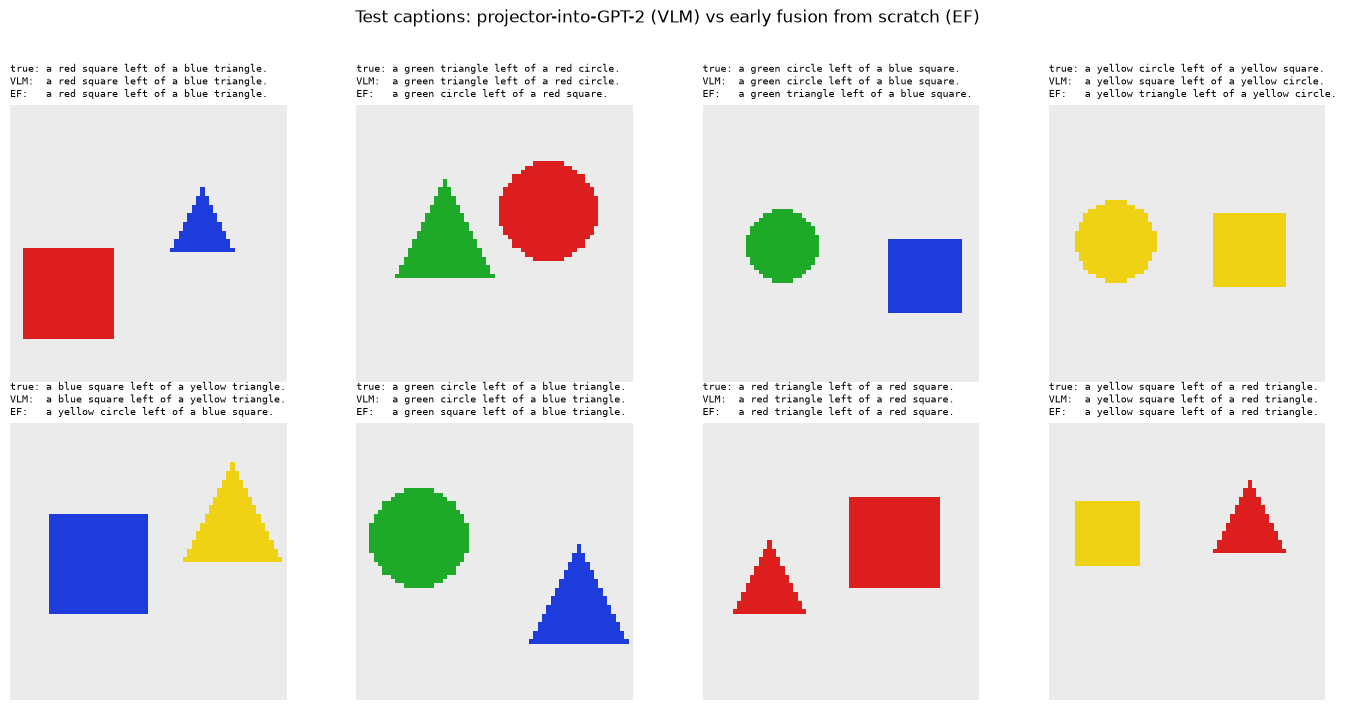

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7.2))
for ax, k in zip(axes.flat, range(8)):
    i = test_ids[k]
    ax.imshow(shape_imgs[i]); ax.axis("off")
    ax.set_title(f"true: {caption_of(shape_objs[i])}\nVLM:  {vlm_caps[k]}\nEF:   {ef_caps[k]}", fontsize=7.5, loc="left", family="monospace")
plt.suptitle("Test captions: projector-into-GPT-2 (VLM) vs early fusion from scratch (EF)"); plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

Same data, same text: the projector into a frozen GPT-2 gets 91% exact captions, the early-fusion transformer trained from scratch 41%, with 5× more steps and more trainable parameters. The per-attribute columns show where early fusion fails: its colors are near perfect (0.99, higher than the VLM's 0.92), but its shapes are right only 59% of the time (chance is 33%). From 2,000 images a small transformer on raw pixels learns color (roughly the mean of a patch) much faster than shape (a pattern inside the patch). CLIP's features already separate shapes, because CLIP was trained on 400M images. The same split shows in the QA column: the early-fusion model answers the color question better (0.90 vs 0.74), in line with its better colors.

This is why VLMs start from a pretrained vision encoder and a pretrained LM. Early fusion from scratch (Chameleon, Fuyu) does work, but with web-scale data and compute; at small data, pretrained components dominate.

✏️ Re-run section 3 with `INIT_SCALE = 1.0` (PyTorch's default). Compare the loss curve and the caption accuracy.

✏️ The two models differ in two ways at once: pretrained CLIP features vs raw pixels, and a frozen pretrained LM vs a transformer trained from scratch. Separate the factors: feed the 5 CLIP visual tokens (`vis`, through a `nn.Linear(768, 128)`) into `EarlyFusion` instead of the pixel patches.

✏️ Data efficiency: retrain both with `N_TR = 250`. Which one degrades more?

## 5. Asking about an object that is not there

Every image has exactly one shape missing. Every training question asked about a shape that *was* in the image, so the model has never seen the answer "there is none". Ask about the missing shape.

In [20]:
absent = [[s for s in SHAPES if s not in (o[0][1], o[1][1])][0] for o in shape_objs]
hall = {}
for name, gen, prompt in [("tiny VLM", vlm_generate, "Question: what color is the {}? Answer:"),
                          ("early fusion", ef_generate, "question: what color is the {}? answer:")]:
    answers = [gen([i], prompt.format(absent[i]), 3)[0].strip(" .") for i in test_ids]
    is_color = [a in COLORS for a in answers]
    copied = [a in (shape_objs[i][0][0], shape_objs[i][1][0]) for a, i in zip(answers, test_ids) if a in COLORS]
    hall[name] = (np.mean(is_color), np.mean(copied), answers)
    print(f"{name:13s} answers with a color: {np.mean(is_color):.2f}   of those, a color that is in the image: {np.mean(copied):.2f}")

chance = np.mean([len({shape_objs[i][0][0], shape_objs[i][1][0]}) / len(COLORS) for i in test_ids])
print(f"chance that a random color is one of the image's colors: {chance:.2f}")

tiny VLM      answers with a color: 0.99   of those, a color that is in the image: 1.00


early fusion  answers with a color: 1.00   of those, a color that is in the image: 1.00
chance that a random color is one of the image's colors: 0.44


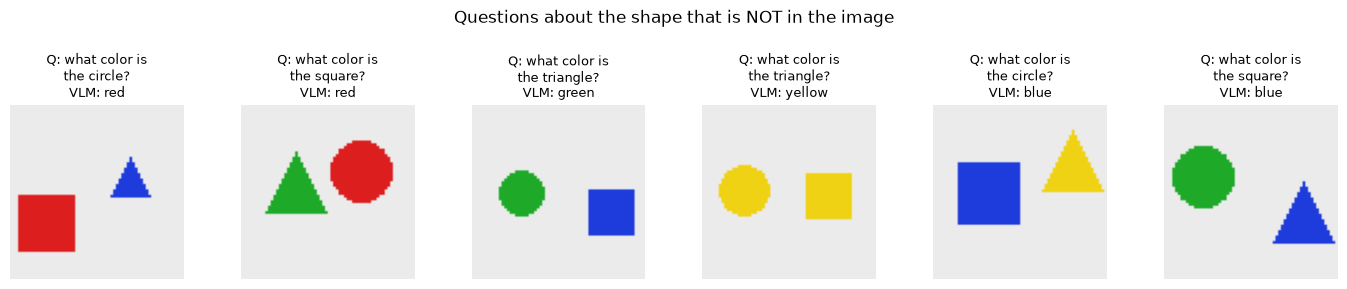

In [21]:
fig, axes = plt.subplots(1, 6, figsize=(14, 2.9))
for ax, k in zip(axes, range(6)):
    i = test_ids[k]
    ax.imshow(shape_imgs[i]); ax.axis("off")
    ax.set_title(f"Q: what color is\nthe {absent[i]}?\nVLM: {hall['tiny VLM'][2][k]}", fontsize=9)
plt.suptitle("Questions about the shape that is NOT in the image"); plt.tight_layout(rect=(0, 0, 1, 0.88)); plt.show()

Asked about the shape that is not there, the tiny VLM names a color for 99% of the questions and the early-fusion model for 100%, and every one of those colors is a color present in the image (a random color would be one of them 44% of the time). The models did not learn "is there a triangle?"; they learned "what color is the X → name a color that is in the image", which was correct for every training question. The answer is grounded in the image (the colors are real) and still wrong (the object is not). This is object hallucination in real VLMs at small scale: instruction data almost never contains questions whose answer is "there is none", so the language prior completes the template.

✏️ Fix it with data: in `sample_text`, with probability 0.2 ask about the absent shape and answer `none.` Retrain the projector and re-run this section. (This is what POPE-style negative questions and "no" answers in instruction data are for.)

## 6. The modality gap

CLIP's image and text embeddings are both unit vectors in the same 512-d space, and matching pairs have the highest cosine. Yet they do not mix: all image embeddings sit in one narrow cone, all text embeddings in another (Liang et al., *Mind the Gap*, NeurIPS 2022). Two causes: (1) a randomly initialized deep encoder already maps all inputs into a narrow cone, and the two encoders start in different cones; (2) the contrastive loss at a low temperature does not pull the cones together; it only needs the *relative* ranking of similarities within the batch.

We measure it on the 500 CIFAR-10 test images and the 80 prompt texts (10 classes × 8 templates).

In [22]:
txt_prompts = [tm.format(c) for c in classes for tm in prompt_sets["8-template ensemble"]]
txt_emb = F.normalize(embed_texts(txt_prompts), dim=-1)                 # (80, 512)
pair_txt = F.normalize(embed_texts([f"a photo of a {classes[c]}." for c in cifar_y.tolist()]), dim=-1)   # matching text per image

def mean_offdiag_cos(A):
    S = A @ A.T
    n = len(A)
    return ((S.sum() - S.diagonal().sum()) / (n * (n - 1))).item()

ii, tt = mean_offdiag_cos(cifar_emb), mean_offdiag_cos(txt_emb)
it = (cifar_emb @ txt_emb.T).mean().item()
paired = (cifar_emb * pair_txt).sum(1).mean().item()
print(f"mean cosine  image–image {ii:.3f}   text–text {tt:.3f}   image–text {it:.3f}   matching image–text pairs {paired:.3f}")
# check against a slow loop on a subset
sub = cifar_emb[:30]
slow = np.mean([F.cosine_similarity(sub[a], sub[b], dim=0).item() for a in range(30) for b in range(30) if a != b])
print("check vs F.cosine_similarity loop: |diff| =", abs(mean_offdiag_cos(sub) - slow))

mean cosine  image–image 0.760   text–text 0.754   image–text 0.213   matching image–text pairs 0.257
check vs F.cosine_similarity loop: |diff| = 1.0632920544040303e-07


gap vector ||mean(img) − mean(txt)|| = 1.045; cosine of PC1 with the gap direction: 1.000


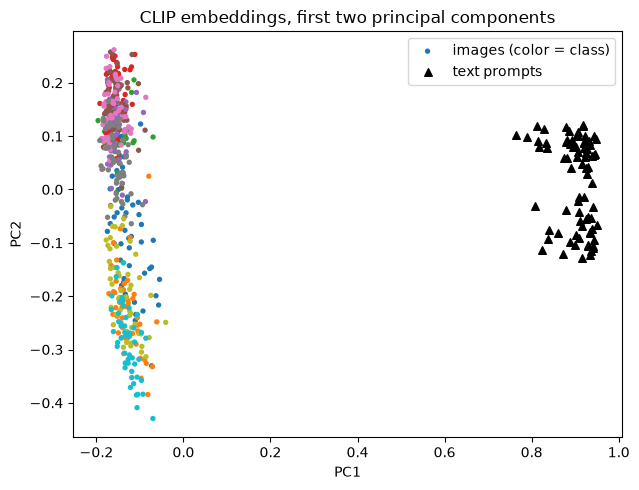

In [23]:
X = torch.cat([cifar_emb, txt_emb]).numpy()
Xc = X - X.mean(0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
Z = Xc @ Vt[:2].T
gap = (cifar_emb.mean(0) - txt_emb.mean(0))
print(f"gap vector ||mean(img) − mean(txt)|| = {gap.norm():.3f}; "
      f"cosine of PC1 with the gap direction: {abs(np.dot(Vt[0], F.normalize(gap, dim=0).numpy())):.3f}")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(Z[:500, 0], Z[:500, 1], s=8, c=cifar_y.numpy(), cmap="tab10", label="images (color = class)")
ax.scatter(Z[500:, 0], Z[500:, 1], s=30, marker="^", c="k", label="text prompts")
ax.set(title="CLIP embeddings, first two principal components", xlabel="PC1", ylabel="PC2"); ax.legend()
plt.tight_layout(); plt.show()

**Effect of the temperature.** Close the gap by hand: move every image embedding by $-\lambda\Delta/2$ and every text embedding by $+\lambda\Delta/2$, where $\Delta$ = mean(image) − mean(text), and re-normalize. $\lambda=0$ is CLIP as trained, $\lambda=1$ makes the two means coincide. Then evaluate the contrastive loss (our `clip_loss`) at three temperatures, on 50 batches of 10 pairs (one image per class, with its "a photo of a {class}." text).

distance between the means: before 1.098, after shift with λ=1: 0.060


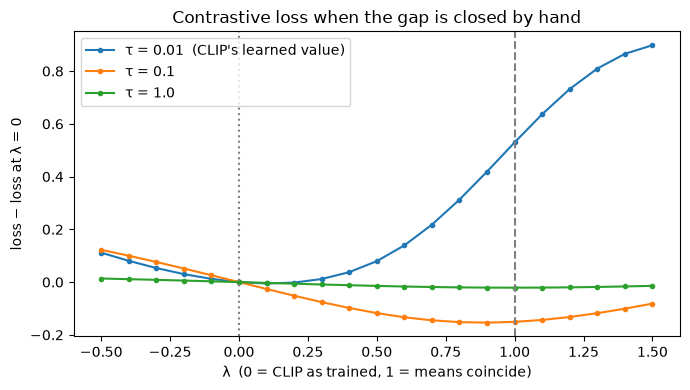

τ = 0.01 : loss at λ=0 0.349, at λ=1 0.879, minimum at λ = 0.1
τ = 0.1  : loss at λ=0 1.830, at λ=1 1.679, minimum at λ = 0.9
τ = 1.0  : loss at λ=0 2.253, at λ=1 2.231, minimum at λ = 1.0


In [24]:
def shift(img, txt, lam, gap):
    return F.normalize(img - lam * gap / 2, dim=-1), F.normalize(txt + lam * gap / 2, dim=-1)

gap_pairs = cifar_emb.mean(0) - pair_txt.mean(0)
a, b = shift(cifar_emb, pair_txt, 1.0, gap_pairs)
print(f"distance between the means: before {gap_pairs.norm():.3f}, after shift with λ=1: {(a.mean(0) - b.mean(0)).norm():.3f}")

lams = np.linspace(-0.5, 1.5, 21)
taus = [0.01, 0.1, 1.0]
curves = {}
for tau in taus:
    ls = []
    for lam in lams:
        a, b = shift(cifar_emb, pair_txt, lam, gap_pairs)
        ls.append(np.mean([clip_loss(a[torch.arange(10) * 50 + j], b[torch.arange(10) * 50 + j],
                                     torch.tensor(math.log(1 / tau))).item() for j in range(50)]))
    curves[tau] = np.array(ls)

fig, ax = plt.subplots(figsize=(7, 4))
for tau in taus:
    ax.plot(lams, curves[tau] - curves[tau][lams.tolist().index(0.0)] if 0.0 in lams else curves[tau], marker="o", ms=3, label=f"τ = {tau}" + ("  (CLIP's learned value)" if tau == 0.01 else ""))
ax.axvline(0, color="gray", ls=":"); ax.axvline(1, color="gray", ls="--")
ax.set(title="Contrastive loss when the gap is closed by hand", xlabel="λ  (0 = CLIP as trained, 1 = means coincide)",
       ylabel="loss − loss at λ = 0"); ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
for tau in taus:
    print(f"τ = {tau:<5}: loss at λ=0 {curves[tau][lams.tolist().index(0.0)] if 0.0 in lams else float('nan'):.3f}, at λ=1 {curves[tau][np.argmin(abs(lams - 1))]:.3f}, minimum at λ = {lams[curves[tau].argmin()]:.1f}")

- Images are similar to each other (mean cosine 0.76) and texts to each other (0.75), but an image and a text have mean cosine 0.21, and **a matching pair only 0.26**: a matching caption is much less similar to its image than a random other image is.
- PC1 is the gap direction (|cosine| = 1.000 with mean(image) − mean(text)) and separates the two modalities completely; the classes are spread along PC2 inside each cone.
- **Temperature.** At CLIP's learned τ = 0.01, the loss is lowest at λ = 0.1, close to CLIP as trained, and closing the gap (λ = 1) raises it from 0.35 to 0.88. At τ = 0.1 and τ = 1 the opposite holds: closing the gap lowers the loss (minimum at λ = 0.9 and 1.0). With a low temperature the loss prefers to keep the gap, so training does not close it.
- Zero-shot classification ranks texts for one image, so a constant offset between the modalities hardly matters there. It matters when image and text embeddings are compared or swapped directly: thresholding image–text cosines, or feeding an image embedding where a model was trained on text embeddings.

✏️ Does closing the gap change zero-shot accuracy? Shift `cifar_emb` and the class weights `W` with λ = 1 and recompute the accuracy of section 2.

## 7. Optional, GPU only: Janus-Pro-1B, one transformer that reads and draws images

`deepseek-ai/Janus-Pro-1B` (≈ 2B parameters in bf16, ≈ 4 GB) follows the decoupled design from the recap: a SigLIP encoder + adaptor feeds **understanding**, a VQ tokenizer (codebook of 16,384, 24×24 = 576 tokens for a 384×384 image) + a generation head handles **generation**, and one autoregressive LLM is shared. The code follows the official repository (https://github.com/deepseek-ai/Janus). On Colab, choose a GPU runtime (T4 is enough); this section is skipped on CPU.

Generation uses **classifier-free guidance** on the image-token logits: each prompt is run twice, once with the text and once with the text replaced by padding, and $\ell = \ell_{\text{uncond}} + w(\ell_{\text{cond}} - \ell_{\text{uncond}})$ with $w=5$.

In [25]:
if device == "cuda":
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/deepseek-ai/Janus.git"], check=True)
    from janus.models import MultiModalityCausalLM, VLChatProcessor
    import requests, io

    janus_path = "deepseek-ai/Janus-Pro-1B"
    vl_chat_processor = VLChatProcessor.from_pretrained(janus_path)
    janus_tok = vl_chat_processor.tokenizer
    vl_gpt = AutoModelForCausalLM.from_pretrained(janus_path, trust_remote_code=True).to(torch.bfloat16).cuda().eval()

    # --- understanding: SigLIP encoder → adaptor → LLM → text ---
    image = Image.open(io.BytesIO(requests.get("http://images.cocodataset.org/val2017/000000039769.jpg", timeout=30).content)).convert("RGB")
    conversation = [
        {"role": "<|User|>", "content": "<image_placeholder>\nDescribe this image. Is there a dog in it?", "images": [image]},
        {"role": "<|Assistant|>", "content": ""},
    ]
    inputs = vl_chat_processor(conversations=conversation, images=[image], force_batchify=True).to(vl_gpt.device)
    inputs_embeds = vl_gpt.prepare_inputs_embeds(**inputs)
    out = vl_gpt.language_model.generate(inputs_embeds=inputs_embeds, attention_mask=inputs.attention_mask,
                                         pad_token_id=janus_tok.eos_token_id, bos_token_id=janus_tok.bos_token_id,
                                         eos_token_id=janus_tok.eos_token_id, max_new_tokens=128, do_sample=False, use_cache=True)
    plt.figure(figsize=(4, 3)); plt.imshow(image); plt.axis("off"); plt.title("input image"); plt.show()
    print(janus_tok.decode(out[0].cpu().tolist(), skip_special_tokens=True))
else:
    print("Section 7 needs a CUDA GPU (Colab: Runtime → Change runtime type → T4 GPU). Skipped on", device)

Section 7 needs a CUDA GPU (Colab: Runtime → Change runtime type → T4 GPU). Skipped on mps


In [26]:
@torch.inference_mode()
def janus_generate(prompt_text, n_images=4, cfg_weight=5.0, temperature=1.0, n_tokens=576, img_size=384, patch=16):
    conversation = [{"role": "<|User|>", "content": prompt_text}, {"role": "<|Assistant|>", "content": ""}]
    sft = vl_chat_processor.apply_sft_template_for_multi_turn_prompts(
        conversations=conversation, sft_format=vl_chat_processor.sft_format, system_prompt="")
    input_ids = torch.LongTensor(janus_tok.encode(sft + vl_chat_processor.image_start_tag))
    tokens = input_ids.repeat(2 * n_images, 1).cuda()
    tokens[1::2, 1:-1] = vl_chat_processor.pad_id                   # odd rows: unconditional (prompt replaced by padding)
    embeds = vl_gpt.language_model.get_input_embeddings()(tokens)
    generated = torch.zeros((n_images, n_tokens), dtype=torch.int).cuda()
    past = None
    for i in range(n_tokens):                                         # next-token prediction over the VQ codebook
        o = vl_gpt.language_model.model(inputs_embeds=embeds, use_cache=True, past_key_values=past)
        past = o.past_key_values
        logits = vl_gpt.gen_head(o.last_hidden_state[:, -1, :])
        logits = logits[1::2] + cfg_weight * (logits[0::2] - logits[1::2])   # classifier-free guidance
        nxt = torch.multinomial(torch.softmax(logits / temperature, dim=-1), 1)
        generated[:, i] = nxt.squeeze(-1)
        embeds = vl_gpt.prepare_gen_img_embeds(nxt.repeat(1, 2).view(-1)).unsqueeze(1)
    dec = vl_gpt.gen_vision_model.decode_code(generated, shape=[n_images, 8, img_size // patch, img_size // patch])
    dec = dec.to(torch.float32).cpu().numpy().transpose(0, 2, 3, 1)
    return np.clip((dec + 1) / 2 * 255, 0, 255).astype(np.uint8)

if device == "cuda":
    prompt_text = "A red circle to the left of a blue square, flat colors, white background"
    imgs = janus_generate(prompt_text)
    fig, axes = plt.subplots(1, len(imgs), figsize=(3 * len(imgs), 3))
    for ax, im in zip(axes, imgs): ax.imshow(im); ax.axis("off")
    plt.suptitle(f"Janus-Pro-1B: {prompt_text!r}"); plt.tight_layout(); plt.show()
else:
    print("Skipped (no CUDA GPU).")

Skipped (no CUDA GPU).


✏️ (GPU) Generate with `cfg_weight=1` (no guidance) and with `cfg_weight=10`. Then ask the understanding pathway about the images you generated: does the model read back what it drew?

## 8. If time: does the prefix-LM mask matter?

In section 4 the visual tokens attended to each other bidirectionally. Replace `prefix_lm_mask` by a fully causal mask (visual token $k$ sees only visual tokens $\le k$) and retrain the early-fusion model. The last text tokens still see every patch, so the information is available either way; what changes is how many layers it takes to combine left and right patches. Compare the caption accuracy.

## Summary
- CLIP = coordination: two encoders, a symmetric InfoNCE loss over the batch's $N\times N$ similarity matrix, a learned temperature ($1/\tau$ = 100, the value it is clipped at). Our loss matches `CLIPModel` to 5e-7.
- Zero-shot classification is a classifier made of text embeddings; prompts matter (88.0% → 89.8% → 91.6% on CIFAR-10 for class name, one template, 8-template ensemble).
- The VLM recipe works at toy scale: frozen CLIP + a linear projector + frozen GPT-2, 0.5% of the parameters trained, 91% exact captions. The projector's initial scale must match the LM's embedding scale.
- With 2,000 images, early fusion from scratch reached 41% exact captions; it learned colors but not shapes. Pretrained components carry the small-data regime.
- A model trained only on questions about present objects answers questions about absent ones with a color taken from the image: hallucination is a data problem before it is a model problem.
- CLIP's image and text embeddings occupy two separate cones (matching-pair cosine 0.26 vs 0.76 within images), and at CLIP's low temperature the contrastive loss prefers to keep the gap.
- Unified models (Chameleon, Janus/Janus-Pro, Transfusion) put image generation in the same transformer; Janus decouples the understanding encoder (SigLIP) from the generation tokenizer (VQ).

**Further watching / reading:** CLIP, https://arxiv.org/abs/2103.00020 ; LLaVA, https://llava-vl.github.io/ ; Qwen3-VL, https://github.com/QwenLM/Qwen3-VL ; Chameleon, https://arxiv.org/abs/2405.09818 ; Transfusion, https://arxiv.org/abs/2408.11039 ; Janus, https://arxiv.org/abs/2410.13848 ; Janus-Pro, https://arxiv.org/abs/2501.17811 ; Stanford CME 296, lecture 4 (CLIP, SigLIP, guidance), https://cme296.stanford.edu/slides/spring26-cme296-lecture4.pdf ; Liang et al., *Mind the Gap* (modality gap), https://arxiv.org/abs/2203.02053 .

In [27]:
print(f"total notebook time: {time.time() - T_START:.0f} s")

total notebook time: 558 s
